# import

In [41]:
import os

import pandas as pd
import pandas.io.sql as sqlio
import psycopg2 as ps

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline

import numpy as np

import warnings

Utilizaremos um case de **análise de crédito** com a ajuda de machine learning.

# Setup inicial

In [42]:
LOCAL = './local/credito/'

O dataset também está disponível no Kaggle [aqui](https://www.kaggle.com/datasets/rikdifos/credit-card-approval-prediction) como `application_record` e `credit_record`, em inglês.

In [43]:
df_clientes = pd.read_csv('https://github.com/alura-tech/alura-tech-pos-data-science-credit-scoring-streamlit/blob/main/dados/clientes_cadastrados.csv?raw=True')
df_aprovados = pd.read_csv('https://github.com/alura-tech/alura-tech-pos-data-science-credit-scoring-streamlit/blob/main/dados/clientes_aprovados.csv?raw=True')

# salvando localmente para fins de backup
df_clientes.to_csv(os.path.join(LOCAL, 'clientes_cadastrados.csv'))
df_aprovados.to_csv(os.path.join(LOCAL, 'aprovados.csv'))

In [44]:
df_clientes.head(3)

,ID_Cliente,Genero,Tem_carro,Tem_casa_propria,Qtd_filhos,Rendimento_anual,Categoria_de_renda,Grau_escolaridade,Estado_civil,Moradia,Idade,Anos_empregado,Tem_celular,Tem_telefone_trabalho,Tem_telefone_fixo,Tem_email,Ocupacao,Tamanho_familia
0,5008804,M,Y,Y,0,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Empregado,Ensino médio,Casado,Casa/apartamento próprio,-21474,-1134,1,0,0,0,Segurança,2.0


In [45]:
df_clientes.shape

(438557, 18)

# 1. Tratando dados

## Duplicatas

In [46]:
df_clientes.ID_Cliente.value_counts()

ID_Cliente
7137299    2
7702238    2
7282535    2
7243768    2
7050948    2
          ..
5690727    1
6621262    1
6621261    1
6621260    1
6842885    1
Name: count, Length: 438510, dtype: int64

In [47]:
df_clientes.duplicated(subset = 'ID_Cliente').sum()

47

In [48]:
repetidos = df_clientes[df_clientes.ID_Cliente.duplicated(keep = False)]

In [49]:
df_clientes_limpo = df_clientes.drop(repetidos.index)

In [50]:
df_clientes_limpo.duplicated(subset = 'ID_Cliente').sum()

0

## Nulos

In [51]:
df_clientes_limpo.isnull().sum()

ID_Cliente                    0
Genero                        0
Tem_carro                     0
Tem_casa_propria              0
Qtd_filhos                    0
Rendimento_anual              0
Categoria_de_renda            0
Grau_escolaridade             0
Estado_civil                  0
Moradia                       0
Idade                         0
Anos_empregado                0
Tem_celular                   0
Tem_telefone_trabalho         0
Tem_telefone_fixo             0
Tem_email                     0
Ocupacao                 134177
Tamanho_familia               0
dtype: int64

In [52]:
df_clientes_limpo.Ocupacao.unique()

array([nan, 'Segurança', 'Vendas', 'Contabilidade', 'Construção Civil',
       'Gerência', 'Motorista', 'Equipe principal', 'Alta tecnologia',
       'Limpeza', 'Serviço privado', 'Cozinha', 'Baixa qualificação',
       'Medicina', 'Secretariado', 'Garçom', 'RH', 'Corretor imobiliário',
       'TI'], dtype=object)

In [53]:
df_clientes_limpo['Ocupacao'] = df_clientes_limpo.Ocupacao.fillna(value = 'Outro')
df_clientes_limpo.isnull().sum()

ID_Cliente               0
Genero                   0
Tem_carro                0
Tem_casa_propria         0
Qtd_filhos               0
Rendimento_anual         0
Categoria_de_renda       0
Grau_escolaridade        0
Estado_civil             0
Moradia                  0
Idade                    0
Anos_empregado           0
Tem_celular              0
Tem_telefone_trabalho    0
Tem_telefone_fixo        0
Tem_email                0
Ocupacao                 0
Tamanho_familia          0
dtype: int64

In [54]:
df_clientes_limpo.nunique()

ID_Cliente               438463
Genero                        2
Tem_carro                     2
Tem_casa_propria              2
Qtd_filhos                   12
Rendimento_anual            866
Categoria_de_renda            5
Grau_escolaridade             5
Estado_civil                  5
Moradia                       6
Idade                     16379
Anos_empregado             9406
Tem_celular                   1
Tem_telefone_trabalho         2
Tem_telefone_fixo             2
Tem_email                     2
Ocupacao                     19
Tamanho_familia              13
dtype: int64

## Remanejando colunas
Iremos retirar a colunas irrelevantes ou redundantes

In [55]:
drop_columns = [
    'Genero',
    "Tem_celular"
]

for col in drop_columns:
    df_clientes_limpo.drop(col, axis = 1, inplace = True)

Padronizando booleanas

In [56]:
df_clientes_limpo.Tem_carro.unique()

array(['Y', 'N'], dtype=object)

In [57]:
df_clientes_limpo.Tem_casa_propria.unique()

array(['Y', 'N'], dtype=object)

In [58]:
df_clientes_limpo.Tem_telefone_trabalho.unique()

array([1, 0], dtype=int64)

In [59]:
df_clientes_limpo.Tem_telefone_fixo.unique()

array([0, 1], dtype=int64)

In [60]:
df_clientes_limpo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 438463 entries, 0 to 438556
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID_Cliente             438463 non-null  int64  
 1   Tem_carro              438463 non-null  object 
 2   Tem_casa_propria       438463 non-null  object 
 3   Qtd_filhos             438463 non-null  int64  
 4   Rendimento_anual       438463 non-null  float64
 5   Categoria_de_renda     438463 non-null  object 
 6   Grau_escolaridade      438463 non-null  object 
 7   Estado_civil           438463 non-null  object 
 8   Moradia                438463 non-null  object 
 9   Idade                  438463 non-null  int64  
 10  Anos_empregado         438463 non-null  int64  
 11  Tem_telefone_trabalho  438463 non-null  int64  
 12  Tem_telefone_fixo      438463 non-null  int64  
 13  Tem_email              438463 non-null  int64  
 14  Ocupacao               438463 non-null  o

In [61]:
YN_columns = ['Tem_carro', 'Tem_casa_propria']

for col in YN_columns:
    df_clientes_limpo[col] = df_clientes_limpo[col].replace(['Y', 'N'], [True, False]).astype('boolean')

D:\Temp\ipykernel_45188\4023681320.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clientes_limpo[col] = df_clientes_limpo[col].replace(['Y', 'N'], [True, False]).astype('boolean')
D:\Temp\ipykernel_45188\4023681320.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clientes_limpo[col] = df_clientes_limpo[col].replace(['Y', 'N'], [True, False]).astype('boolean')


In [62]:
binary_columns = ['Tem_telefone_trabalho', 'Tem_telefone_fixo', 'Tem_email']
for col in binary_columns:
    df_clientes_limpo[col] = df_clientes_limpo[col].astype('boolean')

In [63]:
df_clientes_limpo.head(3)

,ID_Cliente,Tem_carro,Tem_casa_propria,Qtd_filhos,Rendimento_anual,Categoria_de_renda,Grau_escolaridade,Estado_civil,Moradia,Idade,Anos_empregado,Tem_telefone_trabalho,Tem_telefone_fixo,Tem_email,Ocupacao,Tamanho_familia
0,5008804,True,True,0,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,-12005,-4542,True,False,False,Outro,2.0
1,5008805,True,True,0,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,-12005,-4542,True,False,False,Outro,2.0
2,5008806,True,True,0,112500.0,Empregado,Ensino médio,Casado,Casa/apartamento próprio,-21474,-1134,False,False,False,Segurança,2.0


## Dados relacionados à data

Datas estão em "dias atrás". Hoje é 0, -1 é ontem, etc.

In [64]:
df_clientes_limpo.Idade = - df_clientes_limpo.Idade/365.2425
df_clientes_limpo.Anos_empregado = - df_clientes_limpo.Anos_empregado/365.2425

df_clientes_limpo.head()

,ID_Cliente,Tem_carro,Tem_casa_propria,Qtd_filhos,Rendimento_anual,Categoria_de_renda,Grau_escolaridade,Estado_civil,Moradia,Idade,Anos_empregado,Tem_telefone_trabalho,Tem_telefone_fixo,Tem_email,Ocupacao,Tamanho_familia
0,5008804,True,True,0,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,32.868574,12.435574,True,False,False,Outro,2.0
1,5008805,True,True,0,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,32.868574,12.435574,True,False,False,Outro,2.0
2,5008806,True,True,0,112500.0,Empregado,Ensino médio,Casado,Casa/apartamento próprio,58.793815,3.104787,False,False,False,Segurança,2.0
3,5008808,False,True,0,270000.0,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,52.321403,8.353354,False,True,True,Vendas,1.0
4,5008809,False,True,0,270000.0,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,52.321403,8.353354,False,True,True,Vendas,1.0


In [65]:
df_clientes_limpo.Anos_empregado.value_counts()

Anos_empregado
-1000.001369    75314
 0.596864         262
 4.594208         251
 0.681739         241
 2.677673         240
                ...  
 37.041144          1
 27.989623          1
 24.413917          1
 31.291539          1
 22.190736          1
Name: count, Length: 9406, dtype: int64

Substituindo os -1000 (assumidos desempregados)

In [66]:
df_clientes_limpo.loc[df_clientes_limpo.Anos_empregado < 0, 'Anos_empregado'] = 0
df_clientes_limpo.Anos_empregado.value_counts()

Anos_empregado
0.000000     75314
0.596864       262
4.594208       251
0.681739       241
2.677673       240
             ...  
37.041144        1
27.989623        1
24.413917        1
31.291539        1
22.190736        1
Name: count, Length: 9406, dtype: int64

## Verificando correlações, etc

In [67]:
corr = df_clientes_limpo.corr(numeric_only = True)

<Axes: >

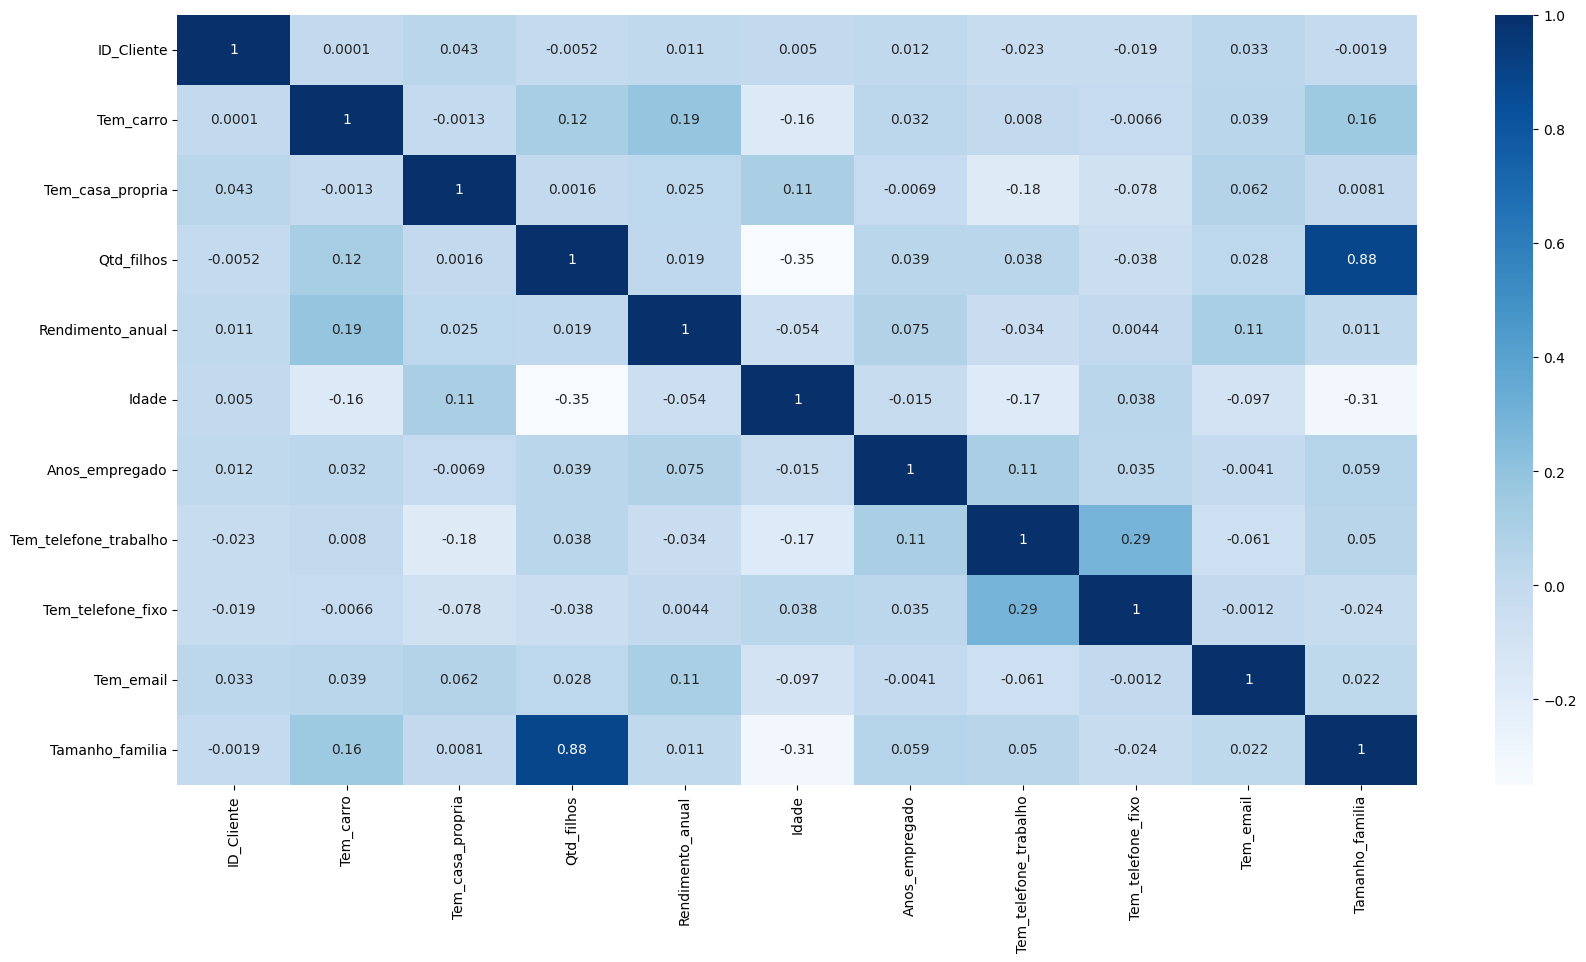

In [68]:
plt.figure(
    figsize = (20, 10),
)

sns.heatmap(
    data = corr,
    cmap = 'Blues',
    annot = True
)

Tamanho_familia e Qtd_filhos quantificam coisas muito similares. Iremos removes Qtd_filhos para evitar redundância

In [69]:
df_clientes_limpo.drop('Qtd_filhos', axis = 1, inplace = True)

## Outliers

In [70]:
'''Técnica para remoção de outliers a partir de um intervalo de confiança
o valor +- o desvio-padrão'''

coluna = df_clientes_limpo['Rendimento_anual']

coluna_med = coluna.mean()
coluna_std = coluna.std()

limite_sup = coluna_med + (2 * coluna_std)
limite_inf = coluna_med - (2 * coluna_std)

index_outliers = []

for index, valor in coluna.items(): 
  if valor > limite_sup or valor < limite_inf:
    index_outliers.append(index)

len(index_outliers)

12641

In [71]:
df_clientes_cadastrados_sem_outliers = df_clientes_limpo.drop(index_outliers)
df_clientes_cadastrados_sem_outliers.shape

(425822, 15)

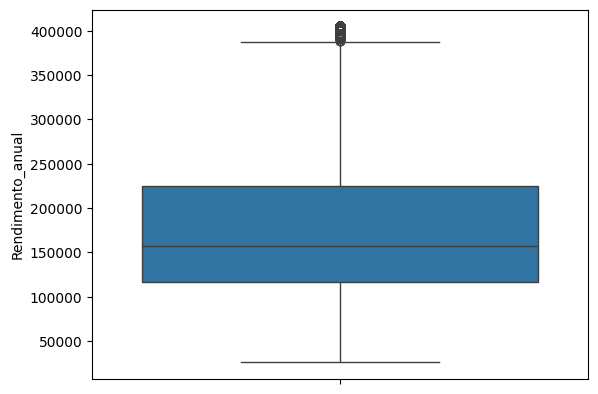

In [72]:
sns.boxplot(data=df_clientes_cadastrados_sem_outliers, y='Rendimento_anual') 
plt.xticks(rotation=45)
plt.show()

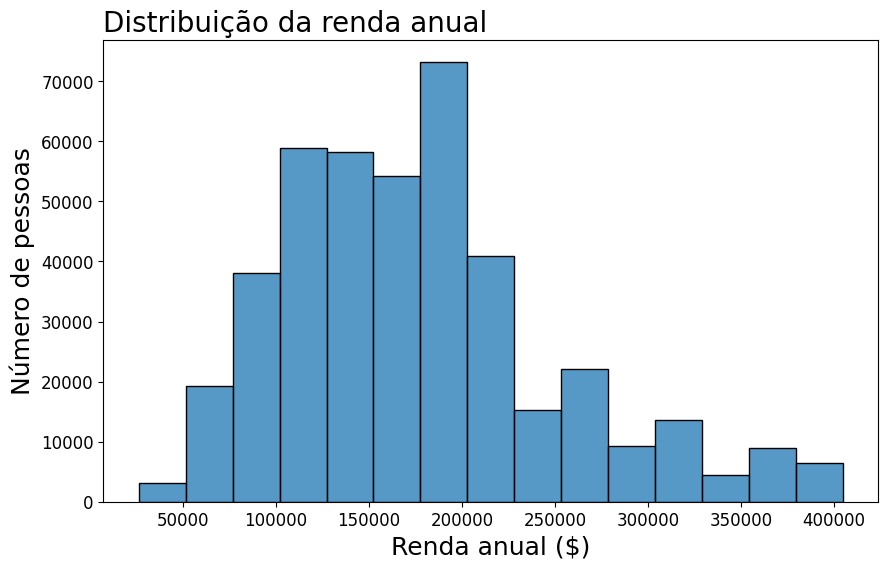

In [73]:
fig = plt.figure(figsize=(10,6))
ax = sns.histplot(data=df_clientes_cadastrados_sem_outliers, x='Rendimento_anual', bins=15)
plt.xticks(rotation=360)
ax.set_title('Distribuição da renda anual', fontsize = 20, loc='left')
ax.set_ylabel('Número de pessoas', fontsize = 18)
ax.set_xlabel('Renda anual ($)', fontsize = 18)
ax.yaxis.set_tick_params(labelsize=12)
ax.xaxis.set_tick_params(labelsize=12)
plt.show()

In [74]:
df_clientes_cadastrados_tratamento1 = df_clientes_cadastrados_sem_outliers
df_clientes_cadastrados_tratamento1.shape

(425822, 15)

## Reordenando as colunas

In [75]:
df_clientes_limpo.columns

Index(['ID_Cliente', 'Tem_carro', 'Tem_casa_propria', 'Rendimento_anual',
       'Categoria_de_renda', 'Grau_escolaridade', 'Estado_civil', 'Moradia',
       'Idade', 'Anos_empregado', 'Tem_telefone_trabalho', 'Tem_telefone_fixo',
       'Tem_email', 'Ocupacao', 'Tamanho_familia'],
      dtype='object')

In [76]:
df_clientes_limpo = df_clientes_limpo[[
    'ID_Cliente',
    'Idade',
    'Ocupacao',
    'Tamanho_familia',
    'Anos_empregado',
    'Rendimento_anual',
    'Categoria_de_renda',
    'Grau_escolaridade',
    'Estado_civil',
    'Moradia',
    'Tem_carro',
    'Tem_casa_propria',
    'Tem_telefone_trabalho',
    'Tem_telefone_fixo',
    'Tem_email',
]]

In [77]:
df_clientes_limpo.head(3)

,ID_Cliente,Idade,Ocupacao,Tamanho_familia,Anos_empregado,Rendimento_anual,Categoria_de_renda,Grau_escolaridade,Estado_civil,Moradia,Tem_carro,Tem_casa_propria,Tem_telefone_trabalho,Tem_telefone_fixo,Tem_email
0,5008804,32.868574,Outro,2.0,12.435574,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,True,True,True,False,False
1,5008805,32.868574,Outro,2.0,12.435574,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,True,True,True,False,False
2,5008806,58.793815,Segurança,2.0,3.104787,112500.0,Empregado,Ensino médio,Casado,Casa/apartamento próprio,True,True,False,False,False


In [78]:
df_clientes_limpo.Categoria_de_renda.value_counts(normalize = True)*100

Categoria_de_renda
Empregado              51.557144
Associado comercial    22.972520
Pensionista            17.214223
Servidor público        8.252236
Estudante               0.003877
Name: proportion, dtype: float64

# 2. Variável Target

In [79]:
df_aprovados.info()
df_aprovados.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID_Cliente      1048575 non-null  int64 
 1   Mes_referencia  1048575 non-null  int64 
 2   Faixa_atraso    1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


,ID_Cliente,Mes_referencia,Faixa_atraso
0,5001711,0,nenhum empréstimo
1,5001711,-1,1-29 dias
2,5001711,-2,1-29 dias


In [80]:
df_aprovados.Faixa_atraso.value_counts()

Faixa_atraso
pagamento realizado    442031
1-29 dias              383120
nenhum empréstimo      209230
30-59 dias              11090
>150 dias                1693
60-89 dias                868
90-119 dias               320
120-149 dias              223
Name: count, dtype: int64

## Criando medidas auxiliares

In [81]:
df_aprovados_by_ID = df_aprovados.groupby('ID_Cliente')

mes_abertura = df_aprovados_by_ID.apply(lambda x : min(x['Mes_referencia']))
mes_abertura.name = 'Mes_Abertura'

mes_final = df_aprovados_by_ID.apply(lambda x : max(x['Mes_referencia']))
mes_final.name = 'Mes_Final'

mes_abertura

D:\Temp\ipykernel_45188\457516417.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mes_abertura = df_aprovados_by_ID.apply(lambda x : min(x['Mes_referencia']))
D:\Temp\ipykernel_45188\457516417.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mes_final = df_aprovados_by_ID.apply(lambda x : max(x['Mes_referencia']))


ID_Cliente
5001711    -3
5001712   -18
5001713   -21
5001714   -14
5001715   -59
           ..
5150482   -28
5150483   -17
5150484   -12
5150485    -1
5150487   -29
Name: Mes_Abertura, Length: 45985, dtype: int64

In [82]:
df_clientes_aprovados = df_aprovados.merge(mes_abertura, on = 'ID_Cliente')
df_clientes_aprovados = df_clientes_aprovados.merge(mes_final, on = 'ID_Cliente')
df_clientes_aprovados.head(3)

,ID_Cliente,Mes_referencia,Faixa_atraso,Mes_Abertura,Mes_Final
0,5001711,0,nenhum empréstimo,-3,0
1,5001711,-1,1-29 dias,-3,0
2,5001711,-2,1-29 dias,-3,0


In [83]:
df_clientes_aprovados['Janela'] = df_clientes_aprovados.Mes_Final - df_clientes_aprovados.Mes_Abertura
df_clientes_aprovados.head()
# Periodo de tempo com o crédito aberto

,ID_Cliente,Mes_referencia,Faixa_atraso,Mes_Abertura,Mes_Final,Janela
0,5001711,0,nenhum empréstimo,-3,0,3
1,5001711,-1,1-29 dias,-3,0,3
2,5001711,-2,1-29 dias,-3,0,3
3,5001711,-3,1-29 dias,-3,0,3
4,5001712,0,pagamento realizado,-18,0,18


In [84]:
df_clientes_aprovados['MOB'] = df_clientes_aprovados.Mes_referencia - df_clientes_aprovados.Mes_Abertura
df_clientes_aprovados.head()

,ID_Cliente,Mes_referencia,Faixa_atraso,Mes_Abertura,Mes_Final,Janela,MOB
0,5001711,0,nenhum empréstimo,-3,0,3,3
1,5001711,-1,1-29 dias,-3,0,3,2
2,5001711,-2,1-29 dias,-3,0,3,1
3,5001711,-3,1-29 dias,-3,0,3,0
4,5001712,0,pagamento realizado,-18,0,18,18


In [85]:
df_clientes_aprovados.Faixa_atraso.unique()

array(['nenhum empréstimo', '1-29 dias', 'pagamento realizado',
       '30-59 dias', '60-89 dias', '90-119 dias', '120-149 dias',
       '>150 dias'], dtype=object)

In [86]:
keys = [
    'nenhum empréstimo', 'pagamento realizado', '1-29 dias', 
       '30-59 dias', '60-89 dias', '90-119 dias', '120-149 dias',
       '>150 dias'
]

dict_faixa_atraso = {keys[x]:x for x in range(len(keys))}
dict_faixa_atraso

{'nenhum empréstimo': 0,
 'pagamento realizado': 1,
 '1-29 dias': 2,
 '30-59 dias': 3,
 '60-89 dias': 4,
 '90-119 dias': 5,
 '120-149 dias': 6,
 '>150 dias': 7}

In [87]:
df_clientes_aprovados['Ind_atraso'] = df_clientes_aprovados.Faixa_atraso.map(dict_faixa_atraso)

df_clientes_aprovados.head(3)

,ID_Cliente,Mes_referencia,Faixa_atraso,Mes_Abertura,Mes_Final,Janela,MOB,Ind_atraso
0,5001711,0,nenhum empréstimo,-3,0,3,3,0
1,5001711,-1,1-29 dias,-3,0,3,2,2
2,5001711,-2,1-29 dias,-3,0,3,1,2


In [88]:
# Bom ou mau pagador
df_clientes_aprovados['Mau_pagador'] = df_clientes_aprovados.apply(lambda x: True if x.Ind_atraso > 3 else False, axis = 1)
df_clientes_aprovados.head(3)

,ID_Cliente,Mes_referencia,Faixa_atraso,Mes_Abertura,Mes_Final,Janela,MOB,Ind_atraso,Mau_pagador
0,5001711,0,nenhum empréstimo,-3,0,3,3,0,False
1,5001711,-1,1-29 dias,-3,0,3,2,2,False
2,5001711,-2,1-29 dias,-3,0,3,1,2,False


In [89]:
df_creditos_ID = df_clientes_aprovados[['ID_Cliente', 'Mes_Abertura', 'Mes_Final', 'Janela']].groupby('ID_Cliente').apply(lambda x : x.iloc[0]).reset_index(drop = True)

D:\Temp\ipykernel_45188\851988606.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_creditos_ID = df_clientes_aprovados[['ID_Cliente', 'Mes_Abertura', 'Mes_Final', 'Janela']].groupby('ID_Cliente').apply(lambda x : x.iloc[0]).reset_index(drop = True)


In [90]:
df_creditos_ID

,ID_Cliente,Mes_Abertura,Mes_Final,Janela
0,5001711,-3,0,3
1,5001712,-18,0,18
2,5001713,-21,0,21
3,5001714,-14,0,14
4,5001715,-59,0,59
...,...,...,...,...
45980,5150482,-28,-11,17
45981,5150483,-17,0,17
45982,5150484,-12,0,12
45983,5150485,-1,0,1


In [91]:
df_denom = df_creditos_ID.groupby('Mes_Abertura').count()[['ID_Cliente']].reset_index()
df_denom.columns = ['Mes_Abertura', 'Qtd_clientes']

df_denom.head(3)

,Mes_Abertura,Qtd_clientes
0,-60,415
1,-59,406
2,-58,440


In [92]:
df_vintage = df_clientes_aprovados.groupby(['Mes_Abertura', 'MOB'])[['ID_Cliente']].count().reset_index()
df_vintage.columns = ['Mes_Abertura', 'MOB', 'Qtd_Clientes']
df_vintage.head()

,Mes_Abertura,MOB,Qtd_Clientes
0,-60,0,415
1,-60,1,414
2,-60,2,410
3,-60,3,408
4,-60,4,403


In [93]:
df_vintage = pd.merge(
    df_vintage[['Mes_Abertura', 'MOB']],
    df_denom,
    on = 'Mes_Abertura',
    how = 'left'
)

In [94]:
df_vintage.head(5)

,Mes_Abertura,MOB,Qtd_clientes
0,-60,0,415
1,-60,1,415
2,-60,2,415
3,-60,3,415
4,-60,4,415


## Taxa de clientes não pagadores

In [95]:
# Wrong code, check later

# df_vintage['Qtd_Mau'] = np.nan

# for j in range(-60, 1):
#     ls = []

#     for i in range(0, 61):
#         due = list(df_clientes_aprovados.query('''
#             (Mau_pagador == False) & (MOB == @i) & (Mes_Abertura == @j)
#         ''')['ID_Cliente'])

#         ls.extend(due)
        
#         df_vintage.loc[(df_vintage['MOB'] == i) & (df_vintage['Mes_Abertura'] == j), 'Qtd_Mau'] = len(set(ls))

In [96]:
df_vintage['Qtd_Mau'] = np.nan

for j in range(-60,1):
    ls = []
    for i in range(0,61):
        due = list(df_clientes_aprovados.query('Mau_pagador == 1 and MOB == @i and Mes_Abertura == @j')['ID_Cliente'])
        ls.extend(due)
        df_vintage.loc[(df_vintage['MOB'] == i) & (df_vintage['Mes_Abertura'] == j), 'Qtd_Mau'] = len(set(ls))

In [97]:
df_vintage['Taxa_de_Mau'] = df_vintage['Qtd_Mau'] / df_vintage['Qtd_clientes']

df_vintage

,Mes_Abertura,MOB,Qtd_clientes,Qtd_Mau,Taxa_de_Mau
0,-60,0,415,0.0,0.000000
1,-60,1,415,0.0,0.000000
2,-60,2,415,0.0,0.000000
3,-60,3,415,0.0,0.000000
4,-60,4,415,0.0,0.000000
...,...,...,...,...,...
1886,-2,1,771,0.0,0.000000
1887,-2,2,771,1.0,0.001297
1888,-1,0,686,0.0,0.000000
1889,-1,1,686,0.0,0.000000


In [98]:
df_vintage_pivot = df_vintage.pivot(
    index = 'Mes_Abertura',
    columns = 'MOB',
    values = 'Taxa_de_Mau'
)

df_vintage_pivot

MOB,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
Mes_Abertura,,,,,,,,,,,,,,,,,,,,,
-60,0.0,0.0,0.000000,0.000000,0.000000,0.002410,0.002410,0.007229,0.007229,0.009639,...,0.028916,0.028916,0.028916,0.028916,0.028916,0.028916,0.028916,0.031325,0.031325,0.031325
-59,0.0,0.0,0.000000,0.004926,0.004926,0.004926,0.007389,0.007389,0.007389,0.012315,...,0.029557,0.029557,0.029557,0.032020,0.032020,0.032020,0.032020,0.032020,0.032020,NaN
-58,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.004545,0.006818,0.006818,...,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,NaN,NaN
-57,0.0,0.0,0.000000,0.000000,0.002500,0.002500,0.002500,0.007500,0.007500,0.007500,...,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,NaN,NaN,NaN
-56,0.0,0.0,0.004255,0.004255,0.008511,0.010638,0.010638,0.017021,0.017021,0.021277,...,0.036170,0.036170,0.036170,0.036170,0.038298,0.038298,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
-4,0.0,0.0,0.000000,0.003432,0.003432,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-3,0.0,0.0,0.001088,0.001088,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-2,0.0,0.0,0.001297,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


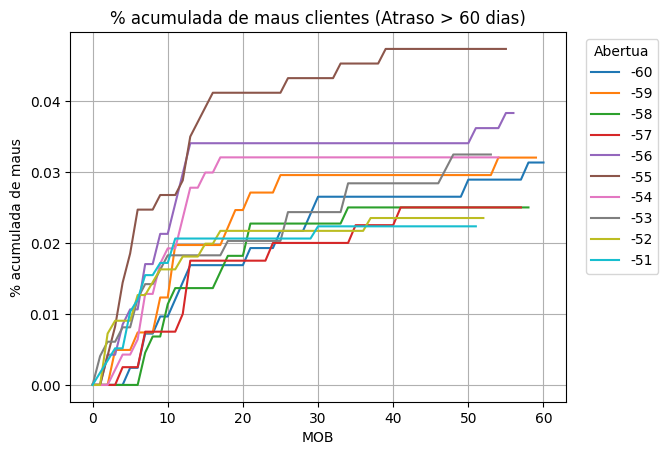

In [99]:
lst = [i for i in range(0, 61)]
df_vintage_pivot[lst].T.iloc[:, :10].plot(
    legend = True,
    grid = True,
    title = '% acumulada de maus clientes (Atraso > 60 dias)'
)

plt.xlabel('MOB')
plt.ylabel('% acumulada de maus')
plt.legend(bbox_to_anchor = (1.2, 1), title = 'Abertua')

plt.show()

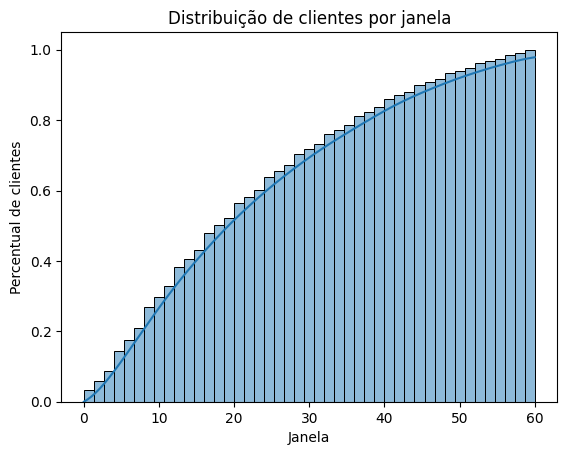

In [100]:
sns.histplot(
    data = df_creditos_ID,
    x = 'Janela',
    cumulative = True,
    stat = 'density',
    kde = True
)

plt.title('Distribuição de clientes por janela')
plt.xlabel('Janela')
plt.ylabel('Percentual de clientes')
plt.show()

In [101]:
dict_intervalo_atraso = {'maior_30_dias': 3, 'maior_60_dias': 4, 'maior_90_dias': 5,
                        'maior_120_dias': 6, 'maior_150_dias': 7}

for chave, valor in dict_intervalo_atraso.items():
  df_clientes_aprovados[f'Mau_{chave}'] = df_clientes_aprovados.apply(lambda x: 1 if x['Ind_atraso'] >= valor else 0, axis=1) # mais de 60
df_clientes_aprovados.head()

,ID_Cliente,Mes_referencia,Faixa_atraso,Mes_Abertura,Mes_Final,Janela,MOB,Ind_atraso,Mau_pagador,Mau_maior_30_dias,Mau_maior_60_dias,Mau_maior_90_dias,Mau_maior_120_dias,Mau_maior_150_dias
0,5001711,0,nenhum empréstimo,-3,0,3,3,0,False,0,0,0,0,0
1,5001711,-1,1-29 dias,-3,0,3,2,2,False,0,0,0,0,0
2,5001711,-2,1-29 dias,-3,0,3,1,2,False,0,0,0,0,0
3,5001711,-3,1-29 dias,-3,0,3,0,2,False,0,0,0,0,0
4,5001712,0,pagamento realizado,-18,0,18,18,1,False,0,0,0,0,0


In [102]:
dict_taxa_mau = {}
id_sum = len(set(df_clientes_aprovados['ID_Cliente']))

for chave in dict_intervalo_atraso.keys():
  df_min_mau = df_clientes_aprovados.query(f'Mau_{chave} == 1').groupby('ID_Cliente')['MOB'].min().reset_index()
  df_mob_taxa_mau = pd.DataFrame({'MOB':range(0,61), 'Taxa_Mau': np.nan})
  lst = []
  for i in range(0,61):
      due = df_min_mau.query('MOB == @i')['ID_Cliente'].to_list()
      lst.extend(due) #cumsum
      df_mob_taxa_mau.loc[df_mob_taxa_mau['MOB'] == i, 'Taxa_Mau'] = len(set(lst)) / id_sum
  dict_taxa_mau[chave] = df_mob_taxa_mau['Taxa_Mau']

df_taxa_mau = pd.DataFrame(dict_taxa_mau)
df_taxa_mau

,maior_30_dias,maior_60_dias,maior_90_dias,maior_120_dias,maior_150_dias
0,0.000304,0.000022,0.000022,0.000022,0.000022
1,0.011612,0.000174,0.000087,0.000087,0.000087
2,0.025878,0.001153,0.000196,0.000174,0.000174
3,0.036860,0.002240,0.000696,0.000304,0.000304
4,0.047385,0.003392,0.001044,0.000696,0.000348
...,...,...,...,...,...
56,0.116321,0.014483,0.007176,0.005263,0.004219
57,0.116321,0.014483,0.007176,0.005263,0.004219
58,0.116321,0.014505,0.007198,0.005284,0.004241
59,0.116321,0.014505,0.007198,0.005284,0.004241


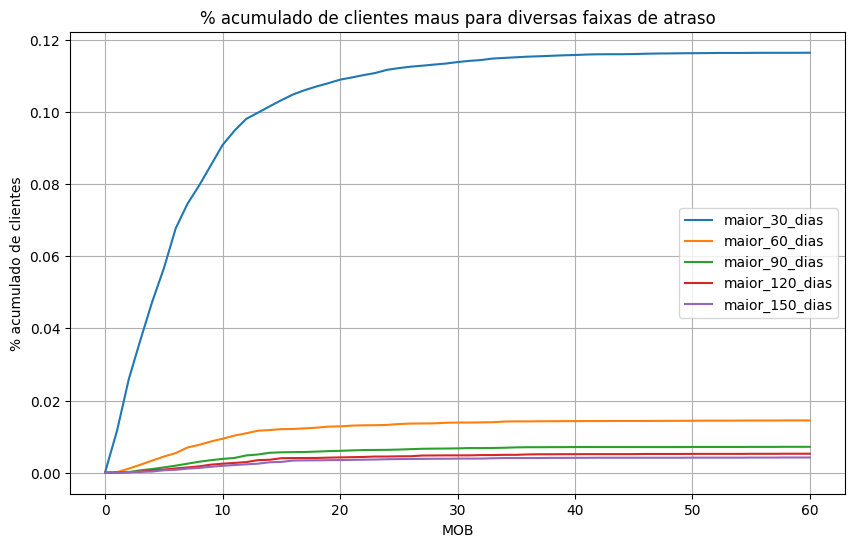

In [103]:
df_taxa_mau.plot(grid = True, title = '% acumulado de clientes maus para diversas faixas de atraso', figsize=(10, 6))
plt.xlabel('MOB')
plt.ylabel('% acumulado de clientes')
plt.show()

## Excluindo histórico < 12 meses

In [104]:
len(df_clientes_aprovados.query('Janela >= 12').groupby('ID_Cliente').count().index)

30918

In [105]:
df_clientes_aprovados_tratamento1 = df_clientes_aprovados.query('Janela >= 12').copy()
df_clientes_aprovados_tratamento1.shape

(943061, 14)

In [106]:
def verifica(registros):
  lista_status = registros['Faixa_atraso'].to_list()
  if '60-89 dias' in lista_status or '90-119 dias' in lista_status or '120-149 dias' in lista_status or '>150 dias' in lista_status:
    return 1
  else:
    return 0
  
df_registros_creditos_id = pd.DataFrame(df_clientes_aprovados_tratamento1.groupby('ID_Cliente').apply(verifica)).reset_index()
df_registros_creditos_id.columns = ['ID_Cliente', 'Mau']
df_registros_creditos_id.head()

D:\Temp\ipykernel_45188\1374363571.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_registros_creditos_id = pd.DataFrame(df_clientes_aprovados_tratamento1.groupby('ID_Cliente').apply(verifica)).reset_index()


,ID_Cliente,Mau
0,5001712,0
1,5001713,0
2,5001714,0
3,5001715,0
4,5001717,0


In [107]:
df_registros_creditos_id.shape

(30918, 2)

In [108]:
df_registro_clientes_targets = df_clientes_cadastrados_tratamento1.merge(df_registros_creditos_id, on='ID_Cliente')
df_registro_clientes_targets.head()

,ID_Cliente,Tem_carro,Tem_casa_propria,Rendimento_anual,Categoria_de_renda,Grau_escolaridade,Estado_civil,Moradia,Idade,Anos_empregado,Tem_telefone_trabalho,Tem_telefone_fixo,Tem_email,Ocupacao,Tamanho_familia,Mau
0,5008806,True,True,112500.0,Empregado,Ensino médio,Casado,Casa/apartamento próprio,58.793815,3.104787,False,False,False,Segurança,2.0,0
1,5008810,False,True,270000.0,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,52.321403,8.353354,False,True,True,Vendas,1.0,0
2,5008811,False,True,270000.0,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,52.321403,8.353354,False,True,True,Vendas,1.0,0
3,5008812,False,True,283500.0,Pensionista,Ensino superior,Divorciado,Casa/apartamento próprio,61.504343,0.000000,False,False,False,Outro,1.0,0
4,5008813,False,True,283500.0,Pensionista,Ensino superior,Divorciado,Casa/apartamento próprio,61.504343,0.000000,False,False,False,Outro,1.0,0


In [109]:
df_registro_clientes_targets['Mau'].value_counts(normalize=True)*100

Mau
0    97.726673
1     2.273327
Name: proportion, dtype: float64

In [141]:
df_registro_clientes_targets['Mau'] = df_registro_clientes_targets['Mau'].astype(bool)

# 3. Machine learning: Construindo a pipeline

In [110]:
SEED = 15611651

In [143]:
df_treino, df_teste = train_test_split(df_registro_clientes_targets,
                                       test_size = 0.2,
                                       random_state = SEED)

In [112]:
df_treino.shape

(18193, 16)

In [113]:
df_teste.shape

(4549, 16)

In [114]:
df_treino_copy = df_treino.copy()
df_teste_copy = df_teste.copy()

# salvando localmente para fins de backup
df_treino.to_csv(os.path.join(LOCAL, 'train.csv'), index = False)
df_teste.to_csv(os.path.join(LOCAL, 'test.csv'), index = False)

## Removendo colunas

In [115]:
# criando uma classe

class DropFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, 
                 to_drop = ['ID_Cliente']) -> None:
        # sera executado quando criamos um objeto dessa classe
        self.to_drop = to_drop
    
    def fit(self, df):
        return self

    def transform(self, df):
        df = df.drop(self.to_drop, axis = 1)
        return df

## Scalers

In [116]:
class MinMax(BaseEstimator, TransformerMixin):
    def __init__(self,
                 to_scale = ['Tamanho_familia',
                                   'Rendimento_anual',
                                   'Idade',
                                   'Anos_empregado']) -> None:
        self.to_scale = to_scale
    
    def fit(self, df):
        return self
    
    def transform(self, df):
        min_max_enc = MinMaxScaler()
        df[self.to_scale] = min_max_enc.fit_transform(df[self.to_scale])
        return df

## Tratando colunas categóricas

In [117]:
class OneHotEncodingNames(BaseEstimator, TransformerMixin):
    def __init__(
            self,
            to_encode = ['Estado_civil', 'Moradia', 'Categoria_de_renda', 'Ocupacao']
    ):
        self.to_encode = to_encode
    
    def fit(self, df):
        return self
    
    def transform(self, df):
        def one_hot_enc(df, encoder):
            one_hot_enc = OneHotEncoder()
            one_hot_enc.fit(df[self.to_encode])

            # pegando o nome das features
            feature_names = one_hot_enc.get_feature_names_out(self.to_encode)

            df = pd.DataFrame(one_hot_enc.transform(df[self.to_encode]).toarray(),
                              columns = feature_names,
                              index = df.index)
            
            return df
        
        def concat_with_rest(df, one_hot_enc_df, to_encode):
            other_features = [feature for feature in df.columns if feature not in to_encode]
            df_concat = pd.concat([one_hot_enc_df, df[other_features]], axis = 1)

            return df_concat
        
        df_ohe = one_hot_enc(df, self.to_encode)

        df_full = concat_with_rest(df, df_ohe, self.to_encode)

        return df_full

## Tratando colunas ordinais

In [118]:
class OrdinalFeature(BaseEstimator, TransformerMixin):
    def __init__(self,
                 to_ordinal = ['Grau_escolaridade']) -> None:
        self.to_ordinal = to_ordinal

    def fit(self, df):
        return self
    
    def transform(self, df):
        ordinal_enc = OrdinalEncoder()
        df[self.to_ordinal] = ordinal_enc.fit_transform(df[self.to_ordinal])        
        return df

## Lidando com undersampling
Temos poucas amostragem em umas das classes. Utilizaremos a estratégia SMOTE, re-amostrando essa classe minoritária.

In [ ]:
class Oversample (BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, df):
        return self
    
    def transform(self, df):
        oversampler = SMOTE(
            sampling_strategy = 'minority'
        )

        X_bal, y_bal = oversampler.fit_resample(df.loc[:, df.columns != 'Mau'], df['Mau'])
        df_bal = pd.concat(
            [pd.DataFrame(X_bal),
             pd.DataFrame(y_bal)],
             axis = 1
        )

        return df_bal

## Pipeline

In [154]:
def my_pipeline(df):
    pipeline = Pipeline([
        ('feature_dropper', DropFeatures()),
        ('OneHotEncoding', OneHotEncodingNames()),
        ('Ordinal_feature', OrdinalFeature()),
        ('min_max_scaler', MinMax()),
        # ('Oversample', Oversample())
    ])

    df_pipeline = pipeline.fit_transform(df)

    return df_pipeline

In [155]:
my_pipeline(df_teste)

,Estado_civil_Casado,Estado_civil_Divorciado,Estado_civil_Solteiro,Estado_civil_União-estável,Estado_civil_Viúvo,Moradia_Apartamento alugado,Moradia_Apartamento comercial,Moradia_Casa/apartamento próprio,Moradia_Cooperativa habitacional,Moradia_Habitação pública,...,Tem_casa_propria,Rendimento_anual,Grau_escolaridade,Idade,Anos_empregado,Tem_telefone_trabalho,Tem_telefone_fixo,Tem_email,Tamanho_familia,Mau
17588,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,True,0.226190,1.0,0.322435,0.112515,False,False,False,0.166667,False
12437,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,False,0.285714,2.0,0.296349,0.194640,True,False,False,0.166667,False
16381,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,True,0.285714,1.0,0.785838,0.000000,False,False,False,0.166667,False
14112,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,True,0.285714,1.0,0.767435,0.000000,False,True,False,0.166667,False
8816,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,True,0.059524,1.0,0.809303,0.000000,False,True,False,0.166667,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21306,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,False,0.226190,1.0,0.756298,0.118500,False,False,False,0.166667,False
17497,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,True,0.642857,1.0,0.590912,0.120096,False,False,False,0.166667,False
5763,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,True,0.142857,1.0,0.297243,0.050738,True,False,False,0.166667,False
21451,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,True,0.404762,1.0,0.848490,0.000000,False,False,False,0.000000,False
